<a href="https://colab.research.google.com/github/Meemansha-spec/EDA-with-Pandas/blob/main/Churn_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
churn_data = pd.read_csv('/content/telecom_customer_churn_cleaned.csv')

In [59]:
churn_data.dtypes.T

,0
customer_id,object
gender,int64
age,int64
married,int64
number_of_dependents,int64
city,object
zip_code,int64
latitude,float64
longitude,float64
number_of_referrals,int64


## Okay! I have this churn dataset which I have already cleaned it and now for the next step I am going to do visualization.

- First step I have done is to look only at the customers who have `stayed` and who have `churned`.

In [60]:
churn_data['customer_status'].value_counts()

,count
customer_status,
Stayed,4720
Churned,1869
Joined,454


- In the next step I have marked all `churned` customers to `1` and `stayed` are `0`.

In [61]:
churn_data['churned']  = churn_data['customer_status'].apply(lambda x: 1 if x == 'Churned' else 0)

In [62]:
churn_data['churned'].value_counts()

,count
churned,
0,5174
1,1869


- There is a column name `tenure_in_months` I have created bins out of it to mark the data in group for easy access.

In [63]:
churn_data['tenure_in_months']

,tenure_in_months
0,9
1,9
2,4
3,13
4,3
...,...
7038,13
7039,22
7040,2
7041,67


### Tenure Groups

In [65]:
bins = [0,12,24,36,48,72]
labels = ['0-12','13-24','25-36','37-48','48+']
churn_data['tenure_group'] = pd.cut(churn_data['tenure_in_months'],bins=bins,labels=labels)

# Let's visualise the data step by step and look at the story

In [66]:
print( "=" * 55)
print( "Telecom Churn Dashboard - The Full Story")
print( "=" * 55)

Telecom Churn Dashboard - The Full Story


# Plot 1: Contract Type - Who is at more Risk?
- We will see how does contract type affects churn, people who have longer contract may have lower churn, usually new customers are quick to leave.Let's see what the data says.

### Which contract should we push customers towards?

- I have calculated the churn rate to see the information clearly.

In [67]:
contract_churn = churn_data.groupby('contract')['churned'].mean() * 100


In [68]:
contract_churn = contract_churn.reset_index()

In [69]:
## rename the columns
contract_churn.columns = ['contract_type','churn_rate_%']

In [70]:
contract_churn

,contract_type,churn_rate_%
0,Month-to-Month,45.844875
1,One Year,10.709677
2,Two Year,2.549124


- I want the data only till two decimal places so I have written this code

In [71]:
contract_churn['churn_rate_%'] = contract_churn['churn_rate_%'].apply(lambda x: '{:.2f}'.format(x))

In [72]:
contract_churn

,contract_type,churn_rate_%
0,Month-to-Month,45.84
1,One Year,10.71
2,Two Year,2.55


In [74]:
contract_churn['contract_type'] = contract_churn['contract_type'].astype('category')
contract_churn['churn_rate_%'] = contract_churn['churn_rate_%'].astype('float')

In [75]:
contract_churn.dtypes

,0
contract_type,category
churn_rate_%,float64


#### Let's Plot the graph

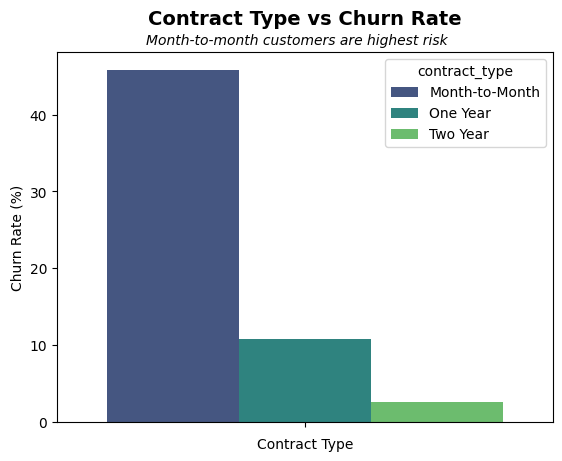

In [81]:
sns.barplot(data=contract_churn, hue ='contract_type', y='churn_rate_%',palette = 'viridis')
plt.title('Contract Type vs Churn Rate', fontsize=14, fontweight='bold', pad=20)
plt.suptitle('Month-to-month customers are highest risk', fontsize=10, style='italic', y=0.92)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)');


### Observation from `Plot 1: Contract Type vs Churn Rate`




- Customers who have joined on monthly service they are highly likely to churn.
- Customers who had 2 year subscription stayed longer

# Plot 2 - When Do they leave?
- Up untill now we have seen that most customers leave on month to month bases,Now we will see in actually how many months they are leaving.

## When should we intervene to save the customer?


In [84]:
churn_by_tenure = churn_data.groupby('tenure_group')['churned'].mean() * 100
churn_by_tenure = churn_by_tenure.reset_index()
churn_by_tenure.columns = ['tenure_group','churn_rate_%']
churn_by_tenure

/tmp/ipykernel_4223/3907458215.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = churn_data.groupby('tenure_group')['churned'].mean() * 100


,tenure_group,churn_rate_%
0,0-12,47.438243
1,13-24,28.710938
2,25-36,21.634615
3,37-48,19.028871
4,48+,9.513176


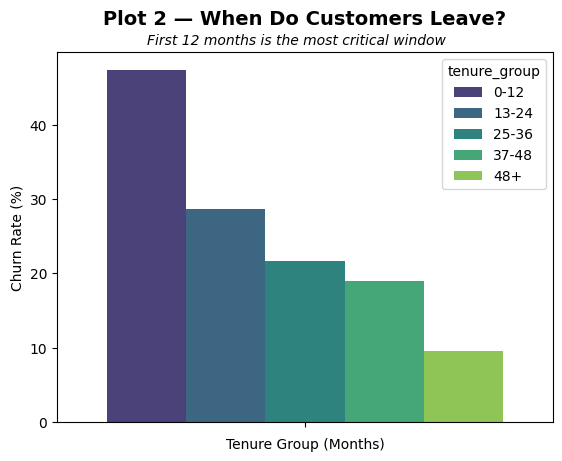

In [87]:
sns.barplot(data = churn_by_tenure , hue = 'tenure_group' , y = 'churn_rate_%',palette = 'viridis')

plt.title('Plot 2 — When Do Customers Leave?',fontsize = 14, fontweight = 'bold',pad = 20)
plt.suptitle('First 12 months is the most critical window', fontsize=10, style='italic', y=0.92)
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate (%)');

# Plot 3 - Why did they leave?
## Is churn a product problem or a people problem?

In [ ]:
category_counts = churn_data['churn_category'].value_counts().reset_index()
category_counts.columns = ['churn_category','count']
category_counts

,churn_category,count
0,Not Churned,4720
1,Competitor,841
2,Dissatisfaction,321
3,Attitude,314
4,Price,211
5,Other,182


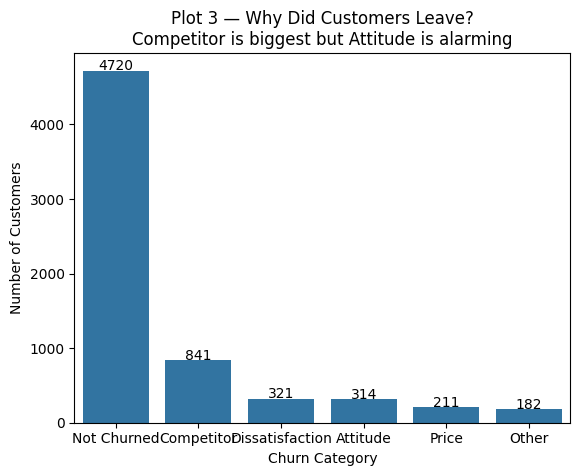

In [ ]:
sns.barplot(data=category_counts, x='churn_category', y='count')
plt.title('Plot 3 — Why Did Customers Leave?\nCompetitor is biggest but Attitude is alarming')
plt.xlabel('Churn Category')
plt.ylabel('Number of Customers')
for i, row in category_counts.reset_index().iterrows():
    plt.text(i, row['count'] + 5, str(row['count']), ha='center', fontsize=10)
plt.show()

# ── Plot 4: Specific Reasons — Top 10 ────────────────────────
## Business question: What exactly needs fixing?

In [ ]:
top_reasons = churn_data['churn_reason'].value_counts().head(10).reset_index()
top_reasons.columns = ['churn_reason','count']
top_reasons

,churn_reason,count
0,Not Churned,4720
1,Competitor had better devices,313
2,Competitor made better offer,311
3,Attitude of support person,220
4,Don't know,130
5,Competitor offered more data,117
6,Competitor offered higher download speeds,100
7,Attitude of service provider,94
8,Price too high,78
9,Product dissatisfaction,77


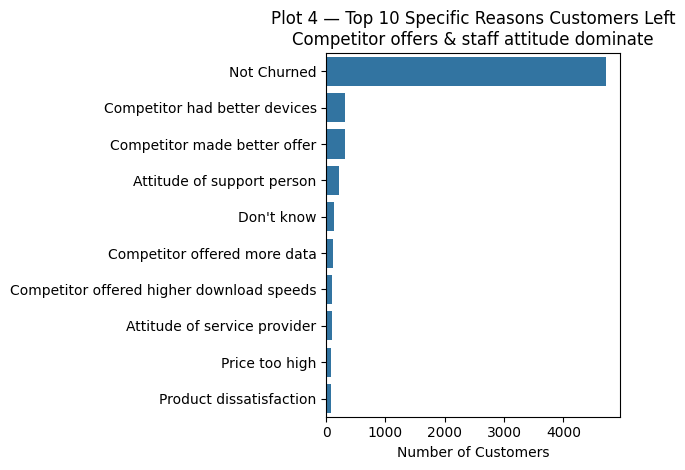

In [ ]:
sns.barplot(data=top_reasons, x='count', y='churn_reason')
plt.title('Plot 4 — Top 10 Specific Reasons Customers Left\nCompetitor offers & staff attitude dominate')
plt.xlabel('Number of Customers')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ── Plot 5: Referral Churn Rate — Loyalty Signal ─────────────
## Business question: Does a referral program reduce churn?

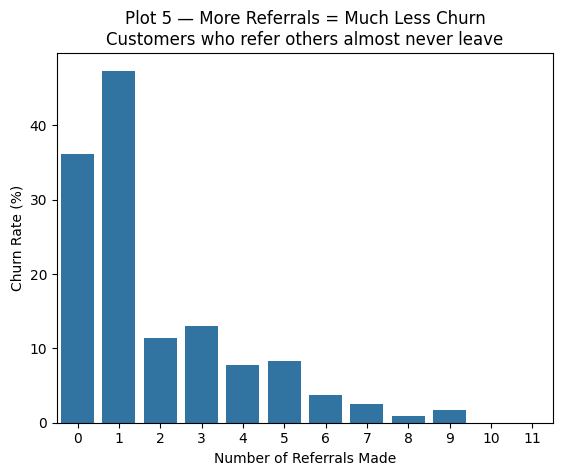

In [ ]:
churn_by_referral = churn_data.groupby('number_of_referrals')['churned'].mean() * 100
churn_by_referral = churn_by_referral.reset_index()
churn_by_referral.columns = ['number_of_referrals', 'churn_rate_%']

sns.barplot(data=churn_by_referral, x='number_of_referrals', y='churn_rate_%')
plt.title('Plot 5 — More Referrals = Much Less Churn\nCustomers who refer others almost never leave')
plt.xlabel('Number of Referrals Made')
plt.ylabel('Churn Rate (%)')
plt.show()

# ── Plot 6: Feature Correlation — Early Warning Signals ───────
## Business question: What signals tell us a customer is about to leave?

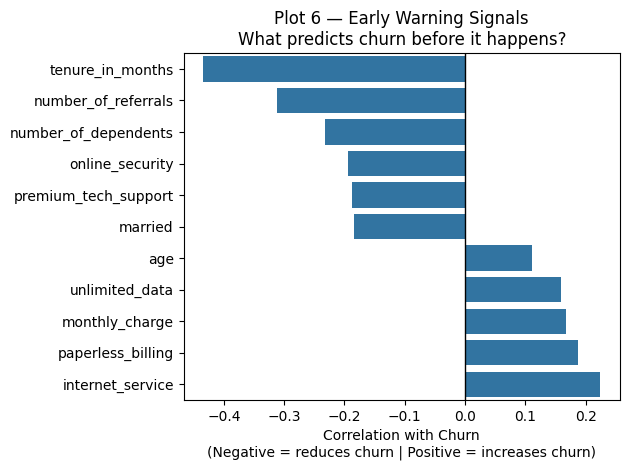

In [ ]:
important_features = [
    'tenure_in_months', 'number_of_referrals',
    'monthly_charge', 'number_of_dependents',
    'online_security', 'premium_tech_support',
    'married', 'age', 'internet_service',
    'paperless_billing', 'unlimited_data'
]

correlations = churn_data[important_features + ['churned']].corr()['churned'].drop('churned').sort_values()

sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Plot 6 — Early Warning Signals\nWhat predicts churn before it happens?')
plt.xlabel('Correlation with Churn\n(Negative = reduces churn | Positive = increases churn)')
plt.ylabel('')
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()
